In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset")

print("Path to dataset files:", path)

100%|██████████| 15.8k/15.8k [00:00<00:00, 24.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset/versions/1


In [ ]:
import os

# List the contents of the directory where the dataset was downloaded
print(f"Contents of {path}:")
for item in os.listdir(path):
    print(item)

Contents of /root/.cache/kagglehub/datasets/ahmeduzaki/global-earthquake-tsunami-risk-assessment-dataset/versions/1:
earthquake_data_tsunami.csv


In [ ]:
import pandas as pd
import os

# Update the file_path to the correct filename found by os.listdir()
file_path = "earthquake_data_tsunami.csv"

# Construct the full file path
full_file_path = os.path.join(path, file_path)

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(full_file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

# Print a concise summary of the DataFrame
print("\nDataFrame Information:")
df.info()

First 5 rows of the DataFrame:
   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Year  Month  tsunami  
0  2022     11        1  
1  2022     11        0  
2  2022     11        1  
3  2022     11        1  
4  2022     11        1  

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig 


Descriptive Statistics for Numerical Columns:
        magnitude         cdi         mmi          sig         nst  \
count  782.000000  782.000000  782.000000   782.000000  782.000000   
mean     6.941125    4.333760    5.964194   870.108696  230.250639   
std      0.445514    3.169939    1.462724   322.465367  250.188177   
min      6.500000    0.000000    1.000000   650.000000    0.000000   
25%      6.600000    0.000000    5.000000   691.000000    0.000000   
50%      6.800000    5.000000    6.000000   754.000000  140.000000   
75%      7.100000    7.000000    7.000000   909.750000  445.000000   
max      9.100000    9.000000    9.000000  2910.000000  934.000000   

             dmin         gap       depth    latitude   longitude  \
count  782.000000  782.000000  782.000000  782.000000  782.000000   
mean     1.325757   25.038990   75.883199    3.538100   52.609199   
std      2.218805   24.225067  137.277078   27.303429  117.898886   
min      0.000000    0.000000    2.700000  -61

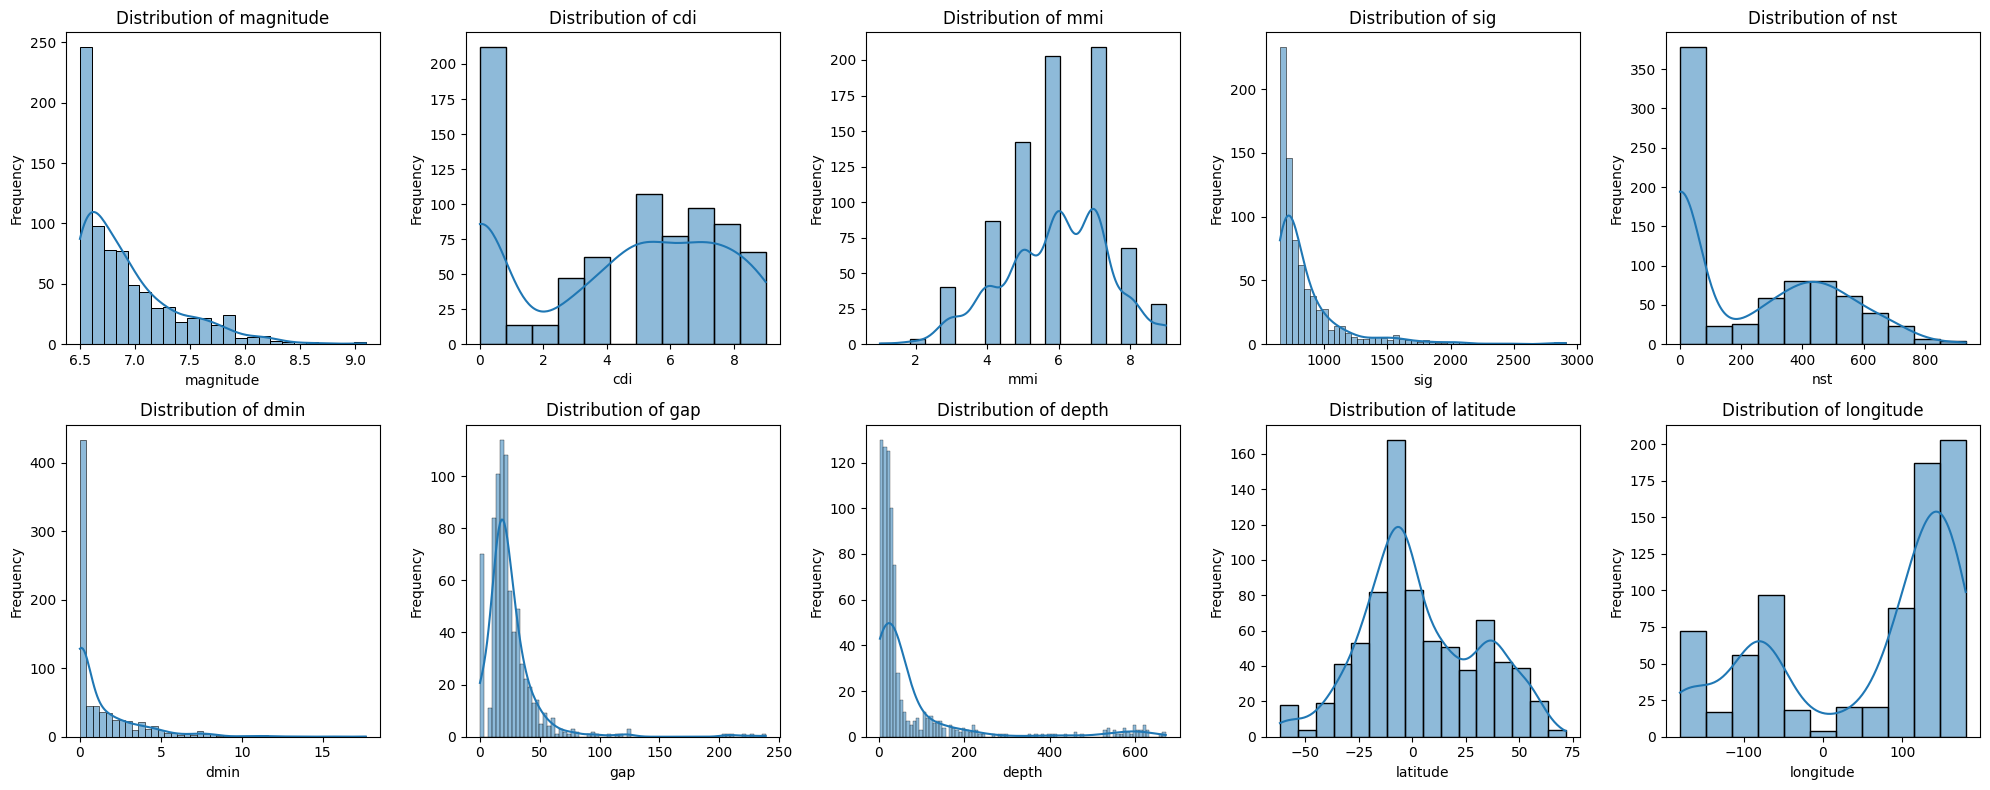

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Display descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())

# 2. For numerical features, create histograms to visualize their distributions
numerical_features = [
    'magnitude','cdi','mmi','sig','nst','dmin', 'gap', 'depth', 'latitude', 'longitude'
]

# Adjust figsize for 2 rows and 5 columns
plt.figure(figsize=(20, 8)) # Adjusted figsize for a 2x5 grid
for i, col in enumerate(numerical_features):
    plt.subplot(2, 5, i + 1) # Changed to 2 rows, 5 columns to accommodate 10 plots
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

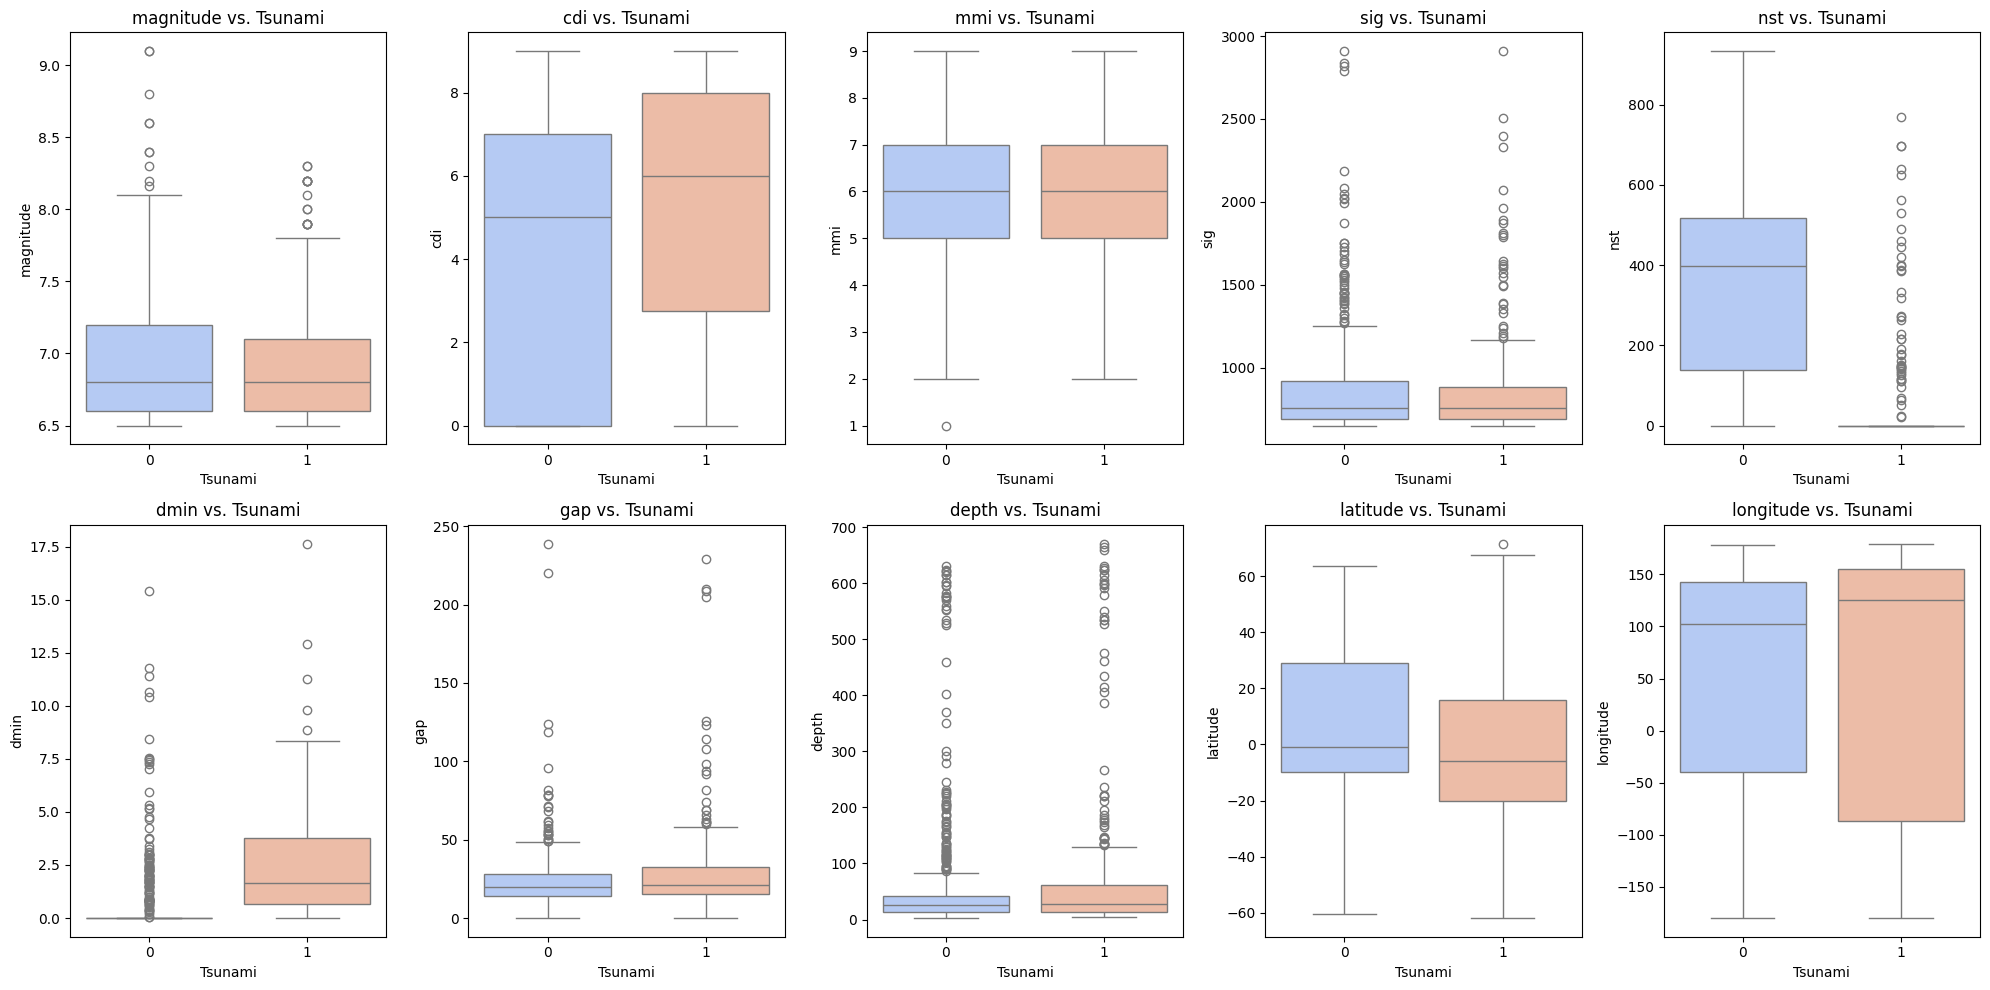

In [ ]:
plt.figure(figsize=(20, 10)) # Adjusted figsize for 2 rows and 5 columns
for i, col in enumerate(numerical_features):
    plt.subplot(2, 5, i + 1) # Changed to 2 rows, 5 columns to accommodate 10 plots
    sns.boxplot(data=df, x='tsunami', y=col, hue='tsunami', palette='coolwarm', legend=False)
    plt.title(f'{col} vs. Tsunami')
    plt.xlabel('Tsunami')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

Class Distribution of Tsunami:
tsunami
0    478
1    304
Name: count, dtype: int64

Percentage:
tsunami
0    61.12532
1    38.87468
Name: proportion, dtype: float64


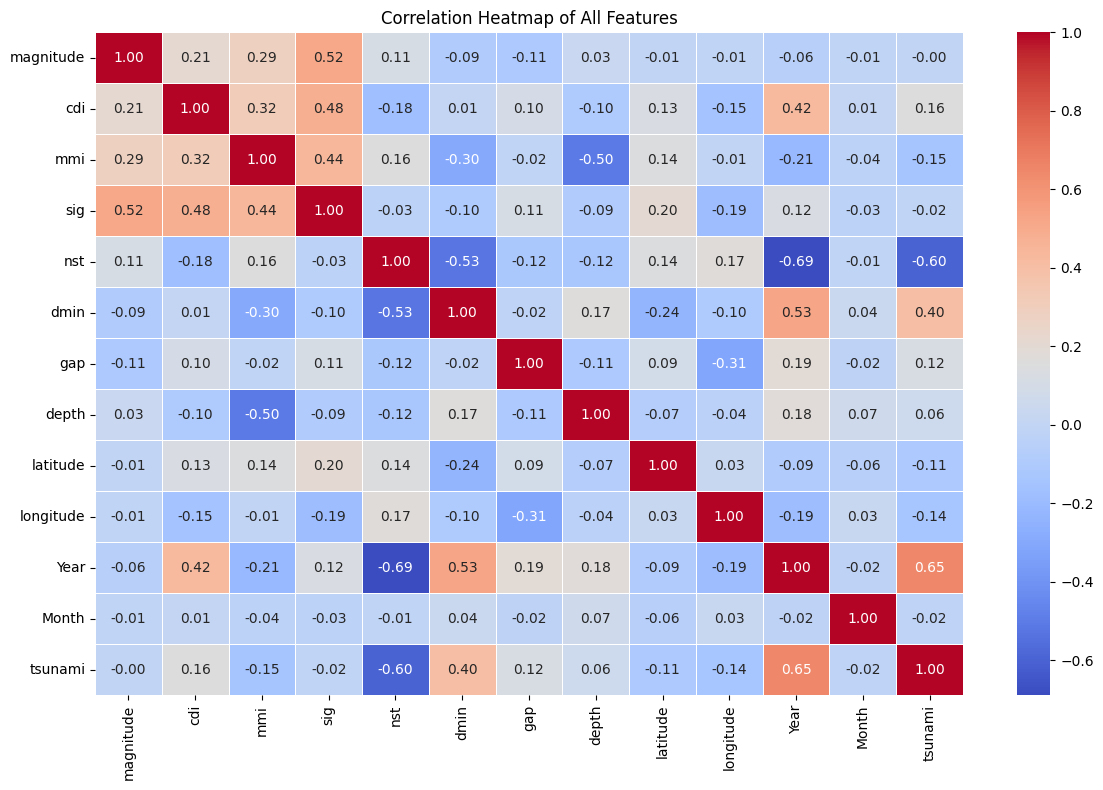

In [ ]:
# Check class distribution of the target variable
# This helps us understand if the dataset is balanced or imbalanced
print("Class Distribution of Tsunami:")
print(df['tsunami'].value_counts())
print(f"\nPercentage:")
print(df['tsunami'].value_counts(normalize=True) * 100)

# Correlation heatmap to understand relationships between features
# This reveals which features are most correlated with tsunami occurrence
# and identifies potential multicollinearity between features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Use the correct column name 'tsunami'
# The data is already 0 and 1, so no mapping is needed
y = df['tsunami']

# 2. Drop the target and the 'Year' column to create the feature set
X = df.drop(['tsunami', 'Year'], axis=1)

print("Shape of feature set X:", X.shape)
print("First 5 rows of X:")
print(X.head())

# 3. Split the data into training and testing sets
# Using stratify=y to ensure both train and test sets maintain the same
# tsunami/no-tsunami ratio, which is important for small datasets (782 rows)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of feature set X: (782, 11)
First 5 rows of X:
   magnitude  cdi  mmi  sig  nst   dmin   gap    depth  latitude  longitude  \
0        7.0    8    7  768  117  0.509  17.0   14.000   -9.7963    159.596   
1        6.9    4    4  735   99  2.229  34.0   25.000   -4.9559    100.738   
2        7.0    3    3  755  147  3.125  18.0  579.000  -20.0508   -178.346   
3        7.3    5    5  833  149  1.865  21.0   37.000  -19.2918   -172.129   
4        6.6    0    2  670  131  4.998  27.0  624.464  -25.5948    178.278   

   Month  
0     11  
1     11  
2     11  
3     11  
4     11  

X_train shape: (625, 11)
X_test shape: (157, 11)
y_train shape: (625,)
y_test shape: (157,)


Decision Tree Classifier Training and Tuning

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 2. Instantiate a DecisionTreeClassifier and train it
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
print("Initial Decision Tree Classifier trained.")

# 3. Make predictions on the X_test data
y_pred_dt = dt_classifier.predict(X_test)
y_proba_dt = dt_classifier.predict_proba(X_test)[:, 1] # Probability for the positive class (1: Tsunami)

# 4. Calculate and print the evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

print("\nInitial Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC AUC Score: {roc_auc_dt:.4f}")

Initial Decision Tree Classifier trained.

Initial Decision Tree Classifier Performance:
Accuracy: 0.8662
Precision: 0.8030
Recall: 0.8689
F1-Score: 0.8346
ROC AUC Score: 0.8667


In [ ]:
from sklearn.model_selection import GridSearchCV

# 5. Define a parameter grid for GridSearchCV
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 6. Instantiate GridSearchCV with the Decision Tree Classifier and parameter grid
grid_search_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    scoring='roc_auc', # Using ROC AUC as a robust metric for classification
    cv=5,
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("Starting GridSearchCV for Decision Tree...")
# 7. Fit GridSearchCV to the X_train and y_train data
grid_search_dt.fit(X_train, y_train)
print("GridSearchCV for Decision Tree completed.")

# 8. Print the best parameters found by GridSearchCV and the best cross-validation score
print("\nBest parameters for Decision Tree Classifier:", grid_search_dt.best_params_)
print("Best cross-validation ROC AUC score for Decision Tree Classifier:", grid_search_dt.best_score_)

Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
GridSearchCV for Decision Tree completed.

Best parameters for Decision Tree Classifier: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation ROC AUC score for Decision Tree Classifier: 0.90840860267552


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 9. Retrain a new DecisionTreeClassifier using the best parameters found
best_dt_classifier = DecisionTreeClassifier(**grid_search_dt.best_params_, random_state=42)
best_dt_classifier.fit(X_train, y_train)
print("Tuned Decision Tree Classifier trained with best parameters.")

# 10. Make predictions on the X_test data using the tuned model
y_pred_tuned_dt = best_dt_classifier.predict(X_test)
y_proba_tuned_dt = best_dt_classifier.predict_proba(X_test)[:, 1] # Probability for the positive class (1: Tsunami)

# 11. Calculate and print the evaluation metrics for the tuned model
accuracy_tuned_dt = accuracy_score(y_test, y_pred_tuned_dt)
precision_tuned_dt = precision_score(y_test, y_pred_tuned_dt)
recall_tuned_dt = recall_score(y_test, y_pred_tuned_dt)
f1_tuned_dt = f1_score(y_test, y_pred_tuned_dt)
roc_auc_tuned_dt = roc_auc_score(y_test, y_proba_tuned_dt)

print("Tuned Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_tuned_dt:.4f}")
print(f"Precision: {precision_tuned_dt:.4f}")
print(f"Recall: {recall_tuned_dt:.4f}")
print(f"F1-Score: {f1_tuned_dt:.4f}")
print(f"ROC AUC Score: {roc_auc_tuned_dt:.4f}")

Tuned Decision Tree Classifier trained with best parameters.
Tuned Decision Tree Classifier Performance:
Accuracy: 0.8854
Precision: 0.8644
Recall: 0.8361
F1-Score: 0.8500
ROC AUC Score: 0.9022


Random Forest Classifier Training and Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Instantiate a RandomForestClassifier and train it
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)
print("Initial Random Forest Classifier trained.")

# 2. Make predictions on the X_test data
y_pred_rf = rf_classifier.predict(X_test)
y_proba_rf = rf_classifier.predict_proba(X_test)[:, 1] # Probability for the positive class (1: Tsunami)

# 3. Calculate and print the evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("\nInitial Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

Initial Random Forest Classifier trained.

Initial Random Forest Classifier Performance:
Accuracy: 0.9045
Precision: 0.8710
Recall: 0.8852
F1-Score: 0.8780
ROC AUC Score: 0.9395


In [ ]:
from sklearn.model_selection import GridSearchCV

# 5. Define a parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [3, 5, 7, 10, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# 6. Instantiate GridSearchCV with the Random Forest Classifier and parameter grid
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='roc_auc', # Using ROC AUC as a robust metric for classification
    cv=5,
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("Starting GridSearchCV for Random Forest...")
# 7. Fit GridSearchCV to the X_train and y_train data
grid_search_rf.fit(X_train, y_train)
print("GridSearchCV for Random Forest completed.")

# 8. Print the best parameters found by GridSearchCV and the best cross-validation score
print("\nBest parameters for Random Forest Classifier:", grid_search_rf.best_params_)
print("Best cross-validation ROC AUC score for Random Forest Classifier:", grid_search_rf.best_score_)

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 135 candidates, totalling 675 fits
GridSearchCV for Random Forest completed.

Best parameters for Random Forest Classifier: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation ROC AUC score for Random Forest Classifier: 0.9389288969176188


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 9. Retrain a new RandomForestClassifier using the best parameters found
best_rf_classifier = RandomForestClassifier(**grid_search_rf.best_params_, random_state=42)
best_rf_classifier.fit(X_train, y_train)
print("Tuned Random Forest Classifier trained with best parameters.")

# 10. Make predictions on the X_test data using the tuned model
y_pred_tuned_rf = best_rf_classifier.predict(X_test)
y_proba_tuned_rf = best_rf_classifier.predict_proba(X_test)[:, 1] # Probability for the positive class (1: Tsunami)

# 11. Calculate and print the evaluation metrics for the tuned model
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)
roc_auc_tuned_rf = roc_auc_score(y_test, y_proba_tuned_rf)

print("\nTuned Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_tuned_rf:.4f}")
print(f"Precision: {precision_tuned_rf:.4f}")
print(f"Recall: {recall_tuned_rf:.4f}")
print(f"F1-Score: {f1_tuned_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_tuned_rf:.4f}")

Tuned Random Forest Classifier trained with best parameters.

Tuned Random Forest Classifier Performance:
Accuracy: 0.8981
Precision: 0.8571
Recall: 0.8852
F1-Score: 0.8710
ROC AUC Score: 0.9389


XGBoost Classifier Training and Tuning

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 2. Instantiate an XGBClassifier and train it
xgb_classifier = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_classifier.fit(X_train, y_train)
print("Initial XGBoost Classifier trained.")

# 3. Make predictions on the X_test data
y_pred_xgb = xgb_classifier.predict(X_test)
y_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1] # Probability for the positive class (1: Tsunami)

# 4. Calculate and print the evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("\nInitial XGBoost Classifier Performance:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC AUC Score: {roc_auc_xgb:.4f}")

Initial XGBoost Classifier trained.

Initial XGBoost Classifier Performance:
Accuracy: 0.9045
Precision: 0.8594
Recall: 0.9016
F1-Score: 0.8800
ROC AUC Score: 0.9443


In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# 5. Define a parameter grid for GridSearchCV
param_grid_xgb = {
    'n_estimators': [50, 100, 200], # Number of boosting rounds
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1.0]
}

# 6. Instantiate GridSearchCV with the XGBoost Classifier and parameter grid
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    scoring='roc_auc', # Using ROC AUC as a robust metric for classification
    cv=5,
    n_jobs=-1, # Use all available cores
    verbose=1
)

print("Starting GridSearchCV for XGBoost...")
# 7. Fit GridSearchCV to the X_train and y_train data
grid_search_xgb.fit(X_train, y_train)
print("GridSearchCV for XGBoost completed.")

# 8. Print the best parameters found by GridSearchCV and the best cross-validation score
print("\nBest parameters for XGBoost Classifier:", grid_search_xgb.best_params_)
print("Best cross-validation ROC AUC score for XGBoost Classifier:", grid_search_xgb.best_score_)

Starting GridSearchCV for XGBoost...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
GridSearchCV for XGBoost completed.

Best parameters for XGBoost Classifier: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation ROC AUC score for XGBoost Classifier: 0.9511839664095303


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 9. Retrain a new XGBClassifier using the best parameters found
best_xgb_classifier = XGBClassifier(**grid_search_xgb.best_params_, random_state=42, eval_metric='logloss')
best_xgb_classifier.fit(X_train, y_train)
print("Tuned XGBoost Classifier trained with best parameters.")

# 10. Make predictions on the X_test data using the tuned model
y_pred_tuned_xgb = best_xgb_classifier.predict(X_test)
y_proba_tuned_xgb = best_xgb_classifier.predict_proba(X_test)[:, 1] # Probability for the positive class (1: Tsunami)

# 11. Calculate and print the evaluation metrics for the tuned model
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)
precision_tuned_xgb = precision_score(y_test, y_pred_tuned_xgb)
recall_tuned_xgb = recall_score(y_test, y_pred_tuned_xgb)
f1_tuned_xgb = f1_score(y_test, y_pred_tuned_xgb)
roc_auc_tuned_xgb = roc_auc_score(y_test, y_proba_tuned_xgb)

print("\nTuned XGBoost Classifier Performance:")
print(f"Accuracy: {accuracy_tuned_xgb:.4f}")
print(f"Precision: {precision_tuned_xgb:.4f}")
print(f"Recall: {recall_tuned_xgb:.4f}")
print(f"F1-Score: {f1_tuned_xgb:.4f}")
print(f"ROC AUC Score: {roc_auc_tuned_xgb:.4f}")

Tuned XGBoost Classifier trained with best parameters.

Tuned XGBoost Classifier Performance:
Accuracy: 0.8981
Precision: 0.8571
Recall: 0.8852
F1-Score: 0.8710
ROC AUC Score: 0.9467


## Model Evaluation and Comparison

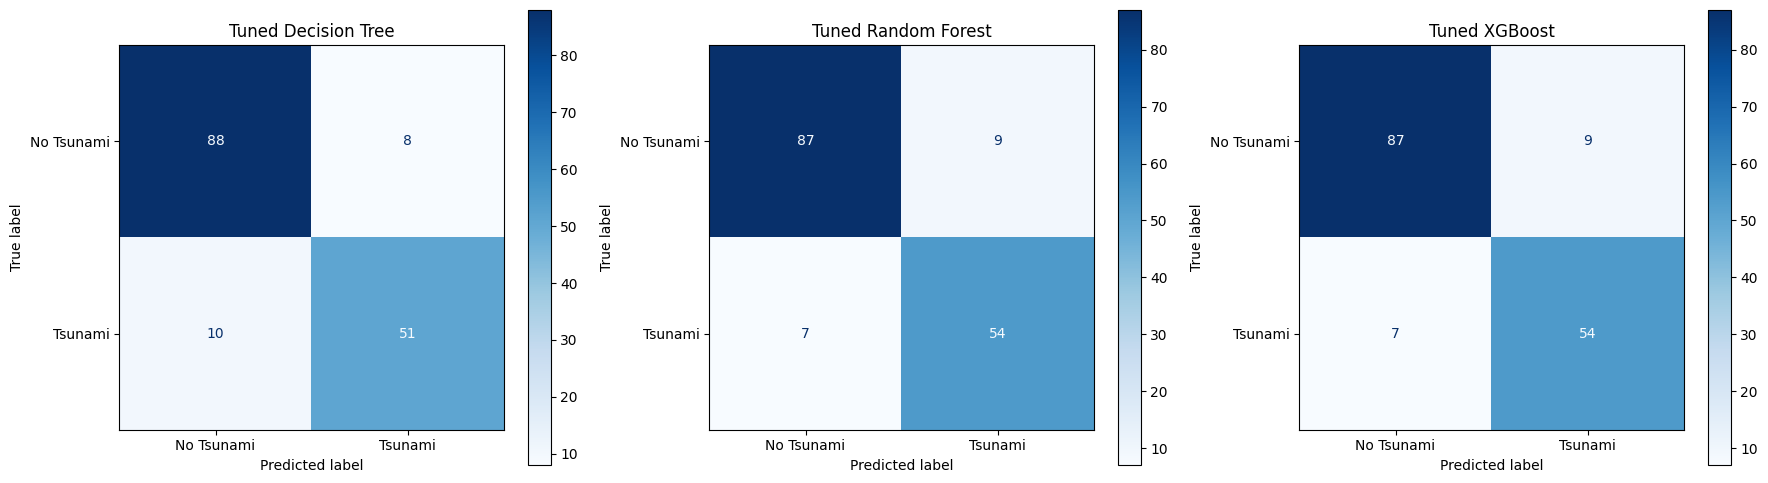

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrices for all tuned models
# For tsunami prediction, recall is critical — a false negative (missing a real tsunami)
# is far more dangerous than a false positive (false alarm)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Tuned Decision Tree': y_pred_tuned_dt,
    'Tuned Random Forest': y_pred_tuned_rf,
    'Tuned XGBoost': y_pred_tuned_xgb
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Tsunami', 'Tsunami'])
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(f'{name}')

plt.tight_layout()
plt.show()

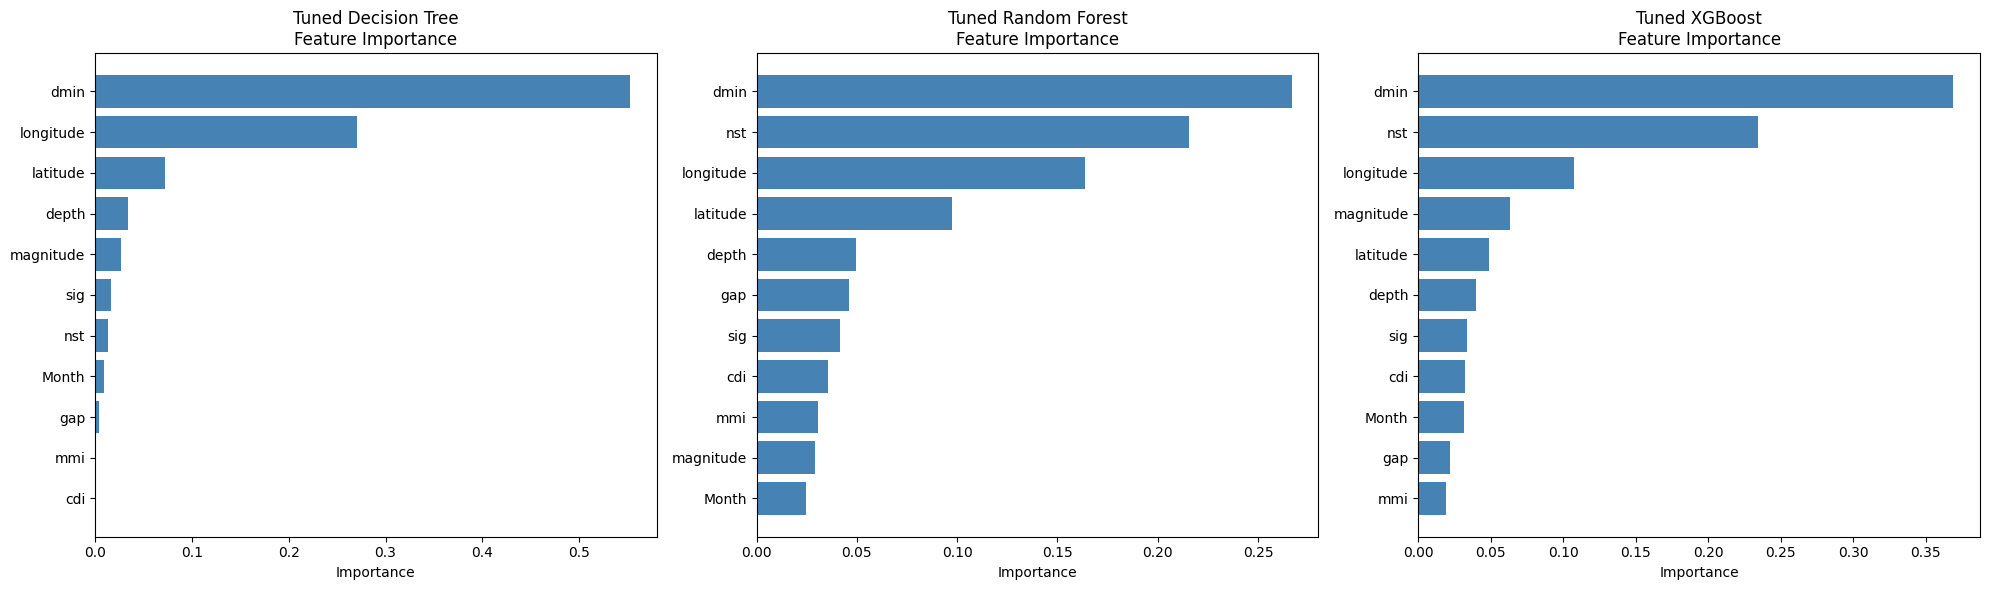

In [ ]:
# Feature Importance Analysis
# Shows which earthquake characteristics contribute most to tsunami prediction
feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

classifiers = {
    'Tuned Decision Tree': best_dt_classifier,
    'Tuned Random Forest': best_rf_classifier,
    'Tuned XGBoost': best_xgb_classifier
}

for ax, (name, clf) in zip(axes, classifiers.items()):
    importances = clf.feature_importances_
    sorted_idx = importances.argsort()
    ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color='steelblue')
    ax.set_title(f'{name}\nFeature Importance')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [ ]:
# Final Model Comparison Table
# Comparing all 6 models (3 initial + 3 tuned) side by side
results = pd.DataFrame({
    'Model': [
        'Decision Tree (Initial)', 'Decision Tree (Tuned)',
        'Random Forest (Initial)', 'Random Forest (Tuned)',
        'XGBoost (Initial)', 'XGBoost (Tuned)'
    ],
    'Accuracy': [
        accuracy_dt, accuracy_tuned_dt,
        accuracy_rf, accuracy_tuned_rf,
        accuracy_xgb, accuracy_tuned_xgb
    ],
    'Precision': [
        precision_dt, precision_tuned_dt,
        precision_rf, precision_tuned_rf,
        precision_xgb, precision_tuned_xgb
    ],
    'Recall': [
        recall_dt, recall_tuned_dt,
        recall_rf, recall_tuned_rf,
        recall_xgb, recall_tuned_xgb
    ],
    'F1-Score': [
        f1_dt, f1_tuned_dt,
        f1_rf, f1_tuned_rf,
        f1_xgb, f1_tuned_xgb
    ],
    'ROC AUC': [
        roc_auc_dt, roc_auc_tuned_dt,
        roc_auc_rf, roc_auc_tuned_rf,
        roc_auc_xgb, roc_auc_tuned_xgb
    ]
})

# Round all numeric columns to 4 decimal places
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(results.to_string(index=False))

# Identify the best model based on ROC AUC (most robust metric for classification)
best_model_idx = results['ROC AUC'].idxmax()
print(f"\nBest Model (by ROC AUC): {results.loc[best_model_idx, 'Model']} "
      f"with ROC AUC = {results.loc[best_model_idx, 'ROC AUC']:.4f}")

# Identify the best model based on Recall (most critical for tsunami prediction)
best_recall_idx = results['Recall'].idxmax()
print(f"Best Model (by Recall): {results.loc[best_recall_idx, 'Model']} "
      f"with Recall = {results.loc[best_recall_idx, 'Recall']:.4f}")
print("\nNote: For tsunami prediction, high recall is critical — missing a real tsunami")
print("(false negative) is far more dangerous than a false alarm (false positive).")

FINAL MODEL COMPARISON
                  Model  Accuracy  Precision  Recall  F1-Score  ROC AUC
Decision Tree (Initial)    0.8662     0.8030  0.8689    0.8346   0.8667
  Decision Tree (Tuned)    0.8854     0.8644  0.8361    0.8500   0.9022
Random Forest (Initial)    0.9045     0.8710  0.8852    0.8780   0.9395
  Random Forest (Tuned)    0.8981     0.8571  0.8852    0.8710   0.9389
      XGBoost (Initial)    0.9045     0.8594  0.9016    0.8800   0.9443
        XGBoost (Tuned)    0.8981     0.8571  0.8852    0.8710   0.9467

Best Model (by ROC AUC): XGBoost (Tuned) with ROC AUC = 0.9467
Best Model (by Recall): XGBoost (Initial) with Recall = 0.9016

Note: For tsunami prediction, high recall is critical — missing a real tsunami
(false negative) is far more dangerous than a false alarm (false positive).
